In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
!wget car_price_prediction.csv.zip

--2026-04-16 13:47:04--  http://car_price_prediction.csv.zip/
Resolving car_price_prediction.csv.zip (car_price_prediction.csv.zip)... 34.206.92.29
Connecting to car_price_prediction.csv.zip (car_price_prediction.csv.zip)|34.206.92.29|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://csv.zip/ [following]
--2026-04-16 13:47:04--  https://csv.zip/
Resolving csv.zip (csv.zip)... 34.206.92.29
Connecting to csv.zip (csv.zip)|34.206.92.29|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8031 (7.8K) [text/html]
Saving to: ‘index.html’

index.html          100%[===================>]   7.84K  --.-KB/s    in 0s      

2026-04-16 13:47:04 (98.3 MB/s) - ‘index.html’ saved [8031/8031]



In [ ]:
df = pd.read_csv('car_price_prediction.csv.zip')
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [ ]:
# Ma'lumotlar hajmini ko'rish
df.shape

(19237, 18)

In [ ]:
# Ma'lumotlar turlarini va bo'sh joylarni yo'qligini tekshirish
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [ ]:
# Ma'lumotlar statistik tahlili (o'rtacha qiymat, dispersiya va anomal qiymatlarni aniqlash)
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [ ]:
# Ma'lumotlarni tozalash va tahlil uchun tayyorlash (Preprocessing)
# Matnli ustunlarni raqamga o'tkszish va xato qiymatlarni filtirlash
df['Model'] = df['Model'].str.split().str[0]
df['Mileage'] = df['Mileage'].str.replace('km','').astype(int)
df['Engine volume'] = df['Engine volume'].str.split().str[0].astype(float)
df['Levy'] = df['Levy'].replace('-', 0).astype(float)
df = df[(df['Price']> 500) & (df['Price']< 100000)]

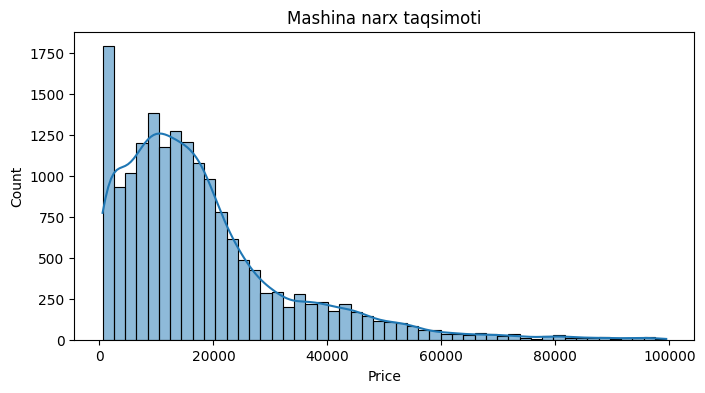

In [ ]:
# Mashina narxlari taqsimotini vizualizatsiya qilish
# Bu grafik narxlarni qaysi diapazonda ko'p uchashini va anomaliyalarni ko'rsatadi
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title("Mashina narx taqsimoti")
plt.show()

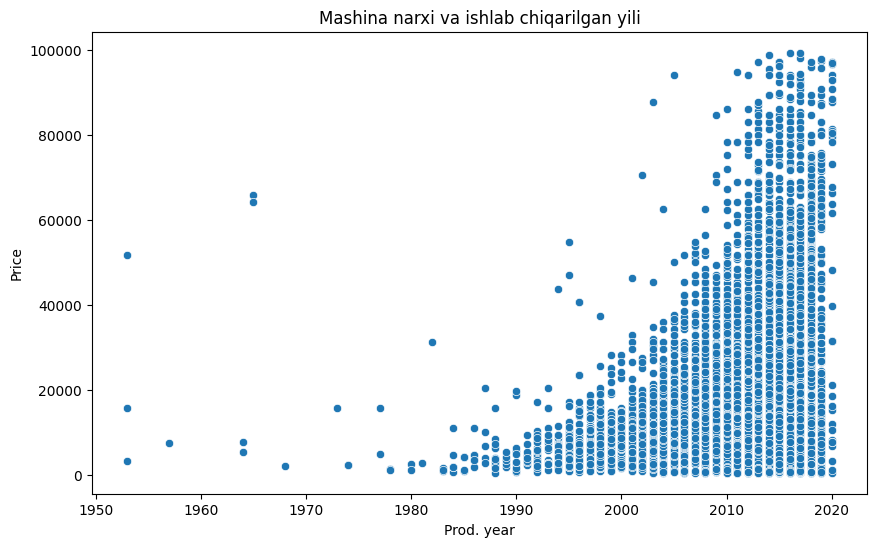

In [ ]:
# Ishlab chiqarilgan yil va narx o'rtasidagi bog'liqlik (Scatter plot)
# Bu grafik mashina yili yangilangan sari narx qanday o'sayotganini ko'rsatadi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Prod. year', y='Price')
plt.title("Mashina narxi va ishlab chiqarilgan yili")
plt.show()

In [ ]:
# Model uchun muhim ustunlarni tanlash va One-Hot Encodingni qo'llash
# Bu jarayon matnli ma'lumotlarni raqamli ko'rinishga (0 va 1) o'tkazadi
selected = ["Price", "Levy", "Manufacturer", "Prod. year", "Category", "Fuel type", "Engine volume", "Mileage", "Cylinders", "Gear box type", "Drive wheels", "Airbags"]
df_copy = df[selected].copy()

# Katigoryalarni raqamlarga aylantirish(One-Hot Encoding)
df_copy = pd.get_dummies(df_copy, columns=["Manufacturer", "Category", "Fuel type", "Gear box type", "Drive wheels"])

# Ma'lumotlar o'lchanini va yangi hosil bo'lgan ustunlarni ko'rish
print(df_copy.shape)
df_copy.head()

(17459, 94)


,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags,Manufacturer_ACURA,Manufacturer_ALFA ROMEO,Manufacturer_ASTON MARTIN,...,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear
0,13328,1399.0,2010,3.5,186005,6.0,12,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,16621,1018.0,2011,3.0,192000,6.0,8,False,False,False,...,False,True,False,False,False,True,False,True,False,False
2,8467,0.0,2006,1.3,200000,4.0,2,False,False,False,...,False,True,False,False,False,False,True,False,True,False
3,3607,862.0,2011,2.5,168966,4.0,0,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,11726,446.0,2014,1.3,91901,4.0,4,False,False,False,...,False,True,False,True,False,False,False,False,True,False


In [ ]:
# Mashinaviy o'qitishga tayyorlash
# X bu yerda 'price' ustunidan boshqa hamma ustunni oladi y faqatgina 'price' ustunini oladi
X = df_copy.drop("Price", axis=1)
y = df_copy["Price"]

In [ ]:
# Ma'lumotlarni X_test va y_test ga bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Modelni Random Forest Regressor algoritimi yordamida o
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Modelni bashorat qilamiz
y_pred = model.predict(X_test)

In [ ]:
# Model sifatini baholash
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

In [ ]:
print(f'Model aniqligi MSE={MSE}, RMSE={RMSE}, R2 score={R2}')

Model aniqligi MSE=43580062.507176444, RMSE=6601.519711943337, R2=0.8108781698637828


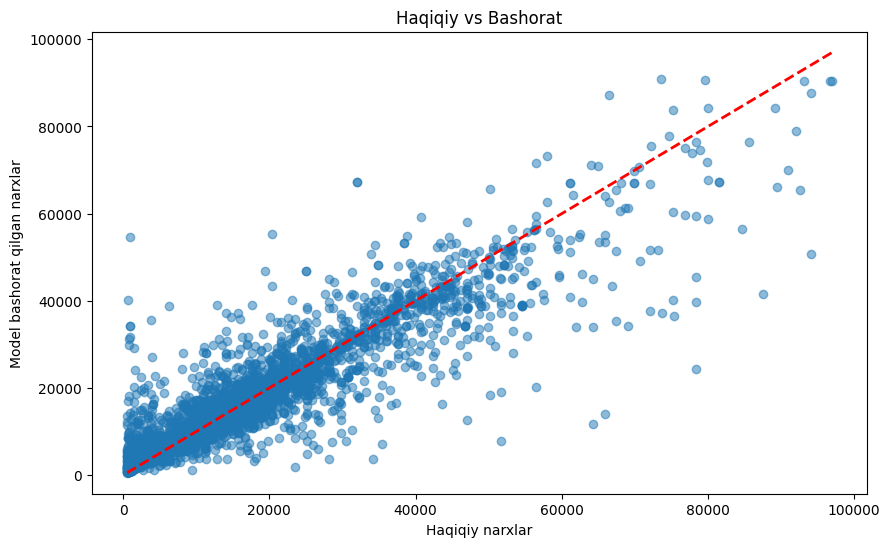

In [ ]:
# Model bashoratlarini haqiqiy qiymatlar bilan solishtirish (Visual Check)
# Qizil chiziq - ideal bashorat chizig'i. Nuqtalar unga yaqin bo'lishi model aniqligini ko'rsatadi
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Haqiqiy narxlar')
plt.ylabel('Model bashorat qilgan narxlar')
plt.title('Haqiqiy vs Bashorat')
plt.show()